**Objective:** Compare all three models side-by-side and declare the "Winning Model".

We will:

Load the saved weights of all three models.

Evaluate all three on the *correct* validation dataset (val_split.csv).

Create a final comparison table of metrics (F1, Accuracy, Precision, Recall).

Plot a bar chart of the F1-Scores.

Plot the confusion matrix for all three models.

Select the winning model for Phase 2.

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import torchmetrics
from tqdm import tqdm
import sys
from pathlib import Path
import os
import numpy as np
print("Libraries imported.")

Libraries imported.


In [2]:
# --- Path Setup ---
print(f"Current working dir: {os.getcwd()}")
project_root = Path(os.getcwd())

# If running from 'notebooks' folder, go one level up
if project_root.name == 'notebooks':
    project_root = project_root.parent

sys.path.append(str(project_root))
sys.path.append(str(project_root / 'src')) # src folder ko path mein add kiya
print(f"Project Root: {project_root}")

Current working dir: d:\Major\FedMedSeg\notebooks
Project Root: d:\Major\FedMedSeg


In [4]:
# --- Import Model Architectures ---

# Model 1 (Basic CNN) ki definition
class Model1_BasicCNN(nn.Module):
    def __init__(self):
        super(Model1_BasicCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(in_features=64 * 56 * 56, out_features=64)
        self.relu3 = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(in_features=64, out_features=1)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.flatten(x)
        x = self.dropout(self.relu3(self.fc1(x)))
        x = self.fc2(x)
        return x

# Model 2 aur 3 ko import karna
try:
    from Models.model2 import DeeperCNN
    from Models.model3 import Model3_MobileNet
    from data_preprocessing import PneumoniaDataset # SAHI validation dataset ke liye
    print("Successfully imported all model architectures and PneumoniaDataset.")
except ImportError as e:
    print(f"ERROR: {e}")

Successfully imported all model architectures and PneumoniaDataset.


In [5]:
# --- Configuration ---
VAL_CSV = project_root / 'data' / 'processed' / 'val_split.csv'
MODEL1_WEIGHTS = project_root / 'models' / 'model_1_basic_cnn_best.pth'
MODEL2_WEIGHTS = project_root / 'model_2_best.pth' # Yeh root folder mein save hua tha
MODEL3_WEIGHTS = project_root / 'models' / 'model_3_mobilenet_best.pth'

BATCH_SIZE = 32
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {DEVICE}")
print(f"Val CSV: {VAL_CSV}")
print(f"Model 1 weights: {MODEL1_WEIGHTS}")
print(f"Model 2 weights: {MODEL2_WEIGHTS}")
print(f"Model 3 weights: {MODEL3_WEIGHTS}")

Using device: cuda
Val CSV: d:\Major\FedMedSeg\data\processed\val_split.csv
Model 1 weights: d:\Major\FedMedSeg\models\model_1_basic_cnn_best.pth
Model 2 weights: d:\Major\FedMedSeg\model_2_best.pth
Model 3 weights: d:\Major\FedMedSeg\models\model_3_mobilenet_best.pth


In [6]:
# --- Load Validation Data (SAHI TAREKA) ---
# ImageNet stats zaroori hain (Model 3 ke liye)
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_dataset = PneumoniaDataset(
    csv_file=VAL_CSV,
    transform=val_transform
)

val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

print(f"Loaded validation data: {len(val_dataset)} images (from val_split.csv).")

Loaded validation data: 1172 images (from val_split.csv).


In [7]:
# --- Load Models ---
print("Loading all 3 models...")
model1 = Model1_BasicCNN().to(DEVICE)
model1.load_state_dict(torch.load(MODEL1_WEIGHTS, map_location=DEVICE))
model1.eval()
print("Loaded Model 1 (Basic CNN).")

model2 = DeeperCNN().to(DEVICE)
model2.load_state_dict(torch.load(MODEL2_WEIGHTS, map_location=DEVICE))
model2.eval()
print("Loaded Model 2 (Deeper CNN).")

model3 = Model3_MobileNet().to(DEVICE)
model3.load_state_dict(torch.load(MODEL3_WEIGHTS, map_location=DEVICE))
model3.eval()
print("Loaded Model 3 (MobileNetV2).")

Loading all 3 models...
Loaded Model 1 (Basic CNN).
Loaded Model 2 (Deeper CNN).
Loaded Model 3 (MobileNetV2).


In [8]:
# --- Evaluation Function ---
def evaluate_model(model, dataloader, device):
    model.eval()
    f1_metric = torchmetrics.F1Score(task="binary").to(device)
    precision_metric = torchmetrics.Precision(task="binary").to(device)
    recall_metric = torchmetrics.Recall(task="binary").to(device)
    accuracy_metric = torchmetrics.Accuracy(task="binary").to(device)
    
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc=f"Evaluating {model.__class__.__name__}"): 
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            preds_proba = torch.sigmoid(outputs).squeeze()
            preds_binary = (preds_proba > 0.5).int()
            
            f1_metric.update(preds_proba, labels)
            precision_metric.update(preds_proba, labels)
            recall_metric.update(preds_proba, labels)
            accuracy_metric.update(preds_proba, labels)
            
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds_binary.cpu().numpy())

    metrics = {
        "Accuracy": accuracy_metric.compute().item(),
        "F1-Score": f1_metric.compute().item(),
        "Precision": precision_metric.compute().item(),
        "Recall": recall_metric.compute().item()
    }
    return metrics, all_labels, all_preds

In [14]:
# %%
# --- Run Evaluation ---
print("Evaluating Model 1 (Basic CNN)...")
try:
    metrics_m1, y_true_m1, y_pred_m1 = evaluate_model(model1, val_loader, DEVICE)
    print("--- DEBUG: metrics_m1 HAS BEEN CREATED. ---") # <-- DEBUG
except Exception as e:
    print(f"--- ERROR WALE EVALUATING MODEL 1: {e} ---") # <-- DEBUG

print("\nEvaluating Model 2 (Deeper CNN)...")
try:
    metrics_m2, y_true_m2, y_pred_m2 = evaluate_model(model2, val_loader, DEVICE)
    print("--- DEBUG: metrics_m2 HAS BEEN CREATED. ---") # <-- DEBUG
except Exception as e:
    print(f"--- ERROR WALE EVALUATING MODEL 2: {e} ---") # <-- DEBUG

print("\nEvaluating Model 3 (MobileNetV2)...")
try:
    metrics_m3, y_true_m3, y_pred_m3 = evaluate_model(model3, val_loader, DEVICE)
    print("--- DEBUG: metrics_m3 HAS BEEN CREATED. ---") # <-- DEBUG
except Exception as e:
    print(f"--- ERROR WALE EVALUATING MODEL 3: {e} ---") # <-- DEBUG

print("\nEvaluation complete.")

Evaluating Model 1 (Basic CNN)...


Evaluating Model1_BasicCNN: 100%|██████████| 37/37 [00:22<00:00,  1.67it/s]


--- DEBUG: metrics_m1 HAS BEEN CREATED. ---

Evaluating Model 2 (Deeper CNN)...


Evaluating DeeperCNN: 100%|██████████| 37/37 [00:25<00:00,  1.47it/s]


--- DEBUG: metrics_m2 HAS BEEN CREATED. ---

Evaluating Model 3 (MobileNetV2)...


Evaluating Model3_MobileNet: 100%|██████████| 37/37 [00:19<00:00,  1.86it/s]

--- DEBUG: metrics_m3 HAS BEEN CREATED. ---

Evaluation complete.


## Final Comparison Table

In [15]:
# --- Comparison Table Banana ---
data = {
    "Model 1 (Basic CNN)": metrics_m1,
    "Model 2 (Deeper CNN)": metrics_m2,
    "Model 3 (MobileNetV2)": metrics_m3
}

df = pd.DataFrame(data).T
df = df[["F1-Score", "Accuracy", "Precision", "Recall"]] # Columns ko order mein rakhna

print("--- FINAL MODEL COMPARISON ---")
display(df)

--- FINAL MODEL COMPARISON ---


,F1-Score,Accuracy,Precision,Recall
Model 1 (Basic CNN),0.936068,0.909556,0.966376,0.907602
Model 2 (Deeper CNN),0.941176,0.913823,0.937355,0.945029
Model 3 (MobileNetV2),0.968658,0.954778,0.979665,0.957895


## Visualization 1: F1-Score Comparison (Bar Chart)

C:\Users\hp\AppData\Local\Temp\ipykernel_33736\775522423.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df.index, y=df['F1-Score'], palette='viridis')


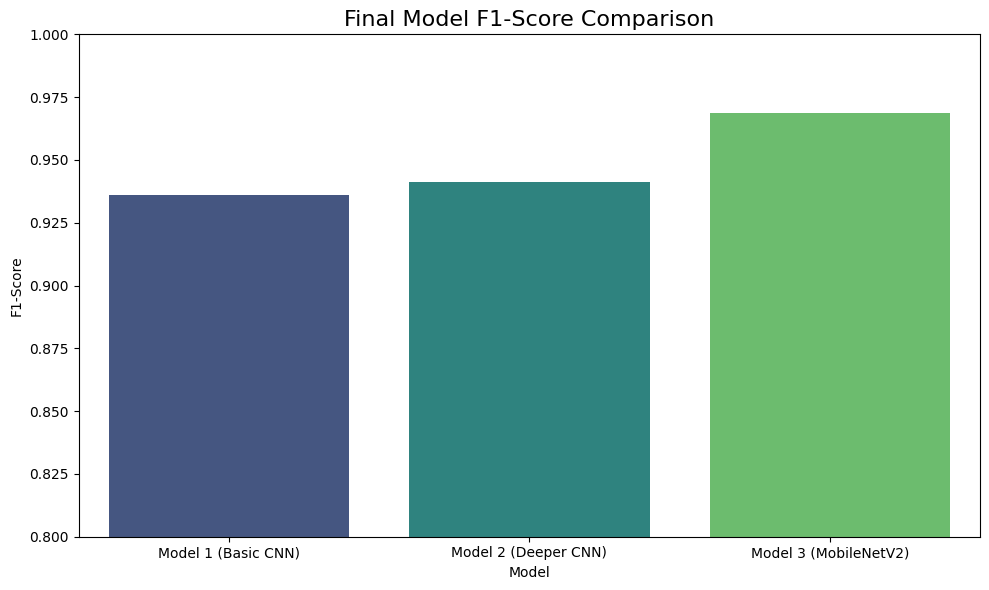

In [17]:
# --- Plot 1: Bar Chart F1-Scores ---
plt.figure(figsize=(10, 6))
sns.barplot(x=df.index, y=df['F1-Score'], palette='viridis')
plt.title('Final Model F1-Score Comparison', fontsize=16)
plt.ylabel('F1-Score')
plt.xlabel('Model')
plt.ylim(0.8, 1.0) # F1-score 0.8 se 1.0 ke beech focus karo
plt.tight_layout()
plt.show()

## Visualization 2: Confusion Matrices

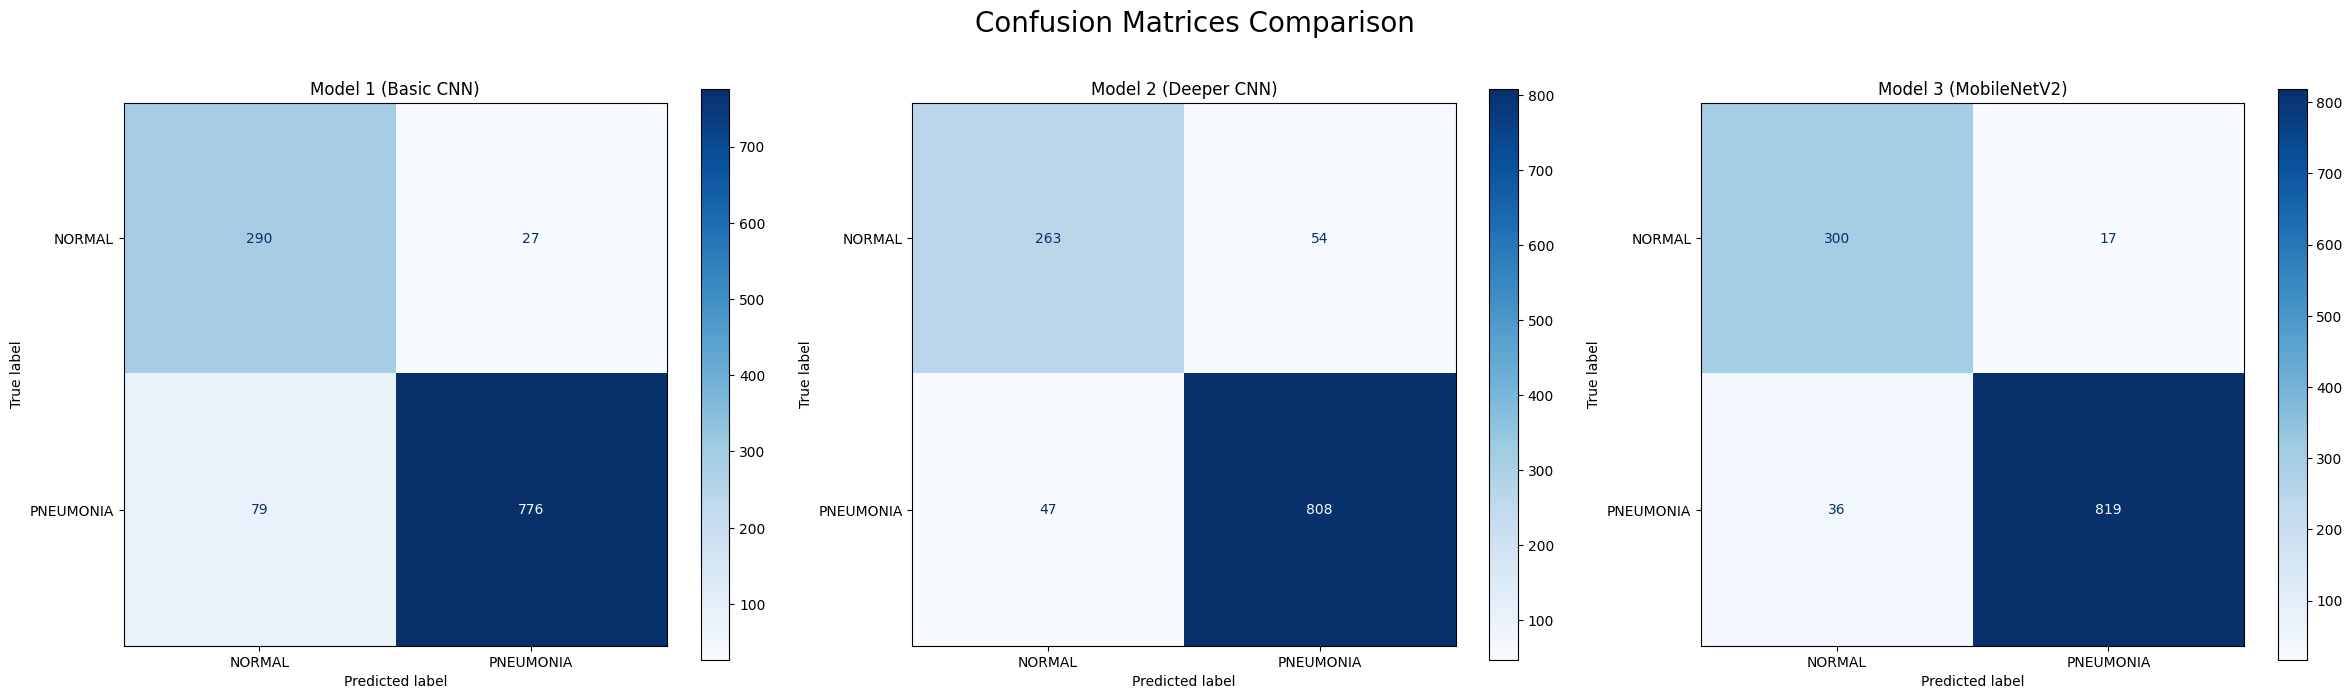

In [18]:
# --- Plot 2: Confusion Matrices ---
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 7))
fig.suptitle('Confusion Matrices Comparison', fontsize=20)
class_names = ['NORMAL', 'PNEUMONIA']

# Model 1
cm1 = confusion_matrix(y_true_m1, y_pred_m1)
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm1, display_labels=class_names)
disp1.plot(ax=ax1, cmap='Blues')
ax1.set_title('Model 1 (Basic CNN)')

# Model 2
cm2 = confusion_matrix(y_true_m2, y_pred_m2)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=class_names)
disp2.plot(ax=ax2, cmap='Blues')
ax2.set_title('Model 2 (Deeper CNN)')

# Model 3
cm3 = confusion_matrix(y_true_m3, y_pred_m3)
disp3 = ConfusionMatrixDisplay(confusion_matrix=cm3, display_labels=class_names)
disp3.plot(ax=ax3, cmap='Blues')
ax3.set_title('Model 3 (MobileNetV2)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Title overlap na ho
plt.show()

## Note on Training History Plots

Aapne training history plots ko compare karne ke liye poocha tha. Hum yeh *nahi* kar sakte kyunki **Model 1** aur **Model 2** ko train karte waqt humne har epoch ka loss ek file mein save nahi kiya tha** (sirf console pe print kiya tha).

Yeh ek bahut important lesson hai: Hamesha training history (loss, accuracy) ko ek file (jaise `.csv` ya `.json`) mein save karna chahiye taaki aap baad mein use plot kar sakein.

Humne `Model 3` ke liye `history` variable banaya tha, lekin woh bhi file mein save nahi hua, isliye jab humne kernel restart kiya, woh data chala gaya.

# 🏆 FINAL VERDICT: The Winning Model 🏆

In [19]:
# --- Final Verdict ---
winner = df['F1-Score'].idxmax()
winner_score = df['F1-Score'].max()

print("--- 🏆 FINAL VERDICT 🏆 ---")
print(f"The 'Winning Classification Model' is: {winner}")
print(f"It achieved the highest F1-Score of: {winner_score:.4f}")
print("\nThis model will be used for Phase 2 (Federated Learning).")
print("--- Phase 1 Complete ---")

--- 🏆 FINAL VERDICT 🏆 ---
The 'Winning Classification Model' is: Model 3 (MobileNetV2)
It achieved the highest F1-Score of: 0.9687

This model will be used for Phase 2 (Federated Learning).
--- Phase 1 Complete ---
